# Trabajo Práctico: Modelado Predictivo - Resistencia del Concreto

**Contexto del Problema:**
La resistencia a la compresión del concreto es una métrica altamente no lineal que depende de sus ingredientes (cemento, agua, agregados, aditivos) y de su tiempo de curado (edad). En ingeniería civil, optimizar esta mezcla es crucial para la seguridad estructural y la eficiencia de costos.

**Objetivo del Laboratorio:**
Su tarea consiste en analizar este fenómeno físico:
1. Construir un modelo base de Regresión Lineal Múltiple.
2. Estandarizar las variables para interpretar correctamente la importancia estadística de cada ingrediente.
3. Utilizar Regresión Polinomial para capturar la relación no lineal subyacente y determinar el punto exacto (grado) donde comienza el sobreajuste (*overfitting*).

**Instrucciones:**
Complete las celdas de código indicadas y responda a las preguntas analíticas basándose en sus resultados.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
import warnings

warnings.filterwarnings('ignore')

print("="*50)
print("CARGA DE DATOS: RESISTENCIA DEL CONCRETO")
print("="*50)

# Enlace para el dataset
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/concrete.csv"
##Para leer de forma local
#url = "../data/concrete.csv"
df = pd.read_csv(url)

# Separar características (X) y variable objetivo (y)
X = df.drop('strength', axis=1)
y = df['strength']

print("Dataset cargado. Dimensiones:", df.shape)
X.head()

CARGA DE DATOS: RESISTENCIA DEL CONCRETO
Dataset cargado. Dimensiones: (1030, 9)


,cement,slag,ash,water,superplastic,coarseagg,fineagg,age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360


### Parte 1: Preparación de Datos y Modelo Base

1. Divida los datos `X` e `y` en un conjunto de entrenamiento (80%) y un conjunto de prueba (20%). Utilice `random_state=42` para reproducibilidad.
2. Inicialice y entrene un modelo de Regresión Lineal Múltiple estándar (OLS) utilizando únicamente los datos de entrenamiento.
3. Calcule el **RMSE** (Error Cuadrático Medio en la raíz) y el **R²** tanto para el conjunto de entrenamiento como para el de prueba. Imprima los resultados.

In [2]:
# ESCRIBA SU CÓDIGO AQUÍ

# 1. División de datos en Entrenamiento y Prueba (Train/Test Split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Entrenamiento del modelo de Regresión Lineal Múltiple
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# 3. Predicciones y cálculo de métricas (RMSE y R²) para Train y Test
y_pred_train = model_lr.predict(X_train)
y_pred_test = model_lr.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print("=" * 50)
print("PARTE 1 — REGRESIÓN LINEAL MÚLTIPLE (OLS)")
print("=" * 50)
print(f"{'Métrica':<20} {'Train':>10} {'Test':>10}")
print("-" * 42)
print(f"{'RMSE':<20} {rmse_train:>10.4f} {rmse_test:>10.4f}")
print(f"{'R²':<20} {r2_train:>10.4f} {r2_test:>10.4f}")

PARTE 1 — REGRESIÓN LINEAL MÚLTIPLE (OLS)
Métrica                   Train       Test
------------------------------------------
RMSE                    10.5188     9.7965
R²                       0.6105     0.6276


### Parte 2: Estandarización e Interpretación de Coeficientes

Dado que los ingredientes del concreto operan en escalas drásticamente distintas (cientos de kg de cemento vs. fracciones de aditivos), los coeficientes del modelo base no son comparables directamente.

1. Aplique `StandardScaler` para estandarizar los conjuntos de entrenamiento y prueba.
2. Entrene un **nuevo** modelo de regresión lineal sobre los datos estandarizados.
3. Extraiga los coeficientes de este modelo estandarizado y genere un gráfico de barras horizontales (`plt.barh`) para visualizar el impacto de cada variable.

PARTE 2 — MODELO ESTANDARIZADO
Métrica                   Train       Test
------------------------------------------
RMSE                    10.5188     9.7965
R²                       0.6105     0.6276


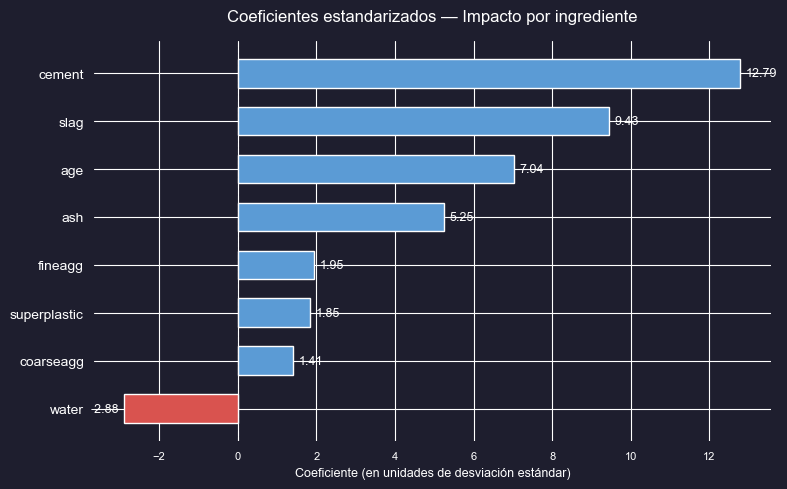

In [3]:
# ESCRIBA SU CÓDIGO AQUÍ

# 1. Estandarización de las características (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # solo usamos fit en train
X_test_scaled  = scaler.transform(X_test)         # transform en test

# 2. Re-entrenamiento del modelo con datos estandarizados
model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, y_train)

y_pred_train_sc = model_scaled.predict(X_train_scaled)
y_pred_test_sc  = model_scaled.predict(X_test_scaled)

rmse_train_sc = np.sqrt(mean_squared_error(y_train, y_pred_train_sc))
rmse_test_sc  = np.sqrt(mean_squared_error(y_test,  y_pred_test_sc))
r2_train_sc   = r2_score(y_train, y_pred_train_sc)
r2_test_sc    = r2_score(y_test,  y_pred_test_sc)

print("=" * 50)
print("PARTE 2 — MODELO ESTANDARIZADO")
print("=" * 50)
print(f"{'Métrica':<20} {'Train':>10} {'Test':>10}")
print("-" * 42)
print(f"{'RMSE':<20} {rmse_train_sc:>10.4f} {rmse_test_sc:>10.4f}")
print(f"{'R²':<20} {r2_train_sc:>10.4f} {r2_test_sc:>10.4f}")

# 3. Extracción y visualización de los coeficientes estandarizados

coef_df = pd.DataFrame({
    'variable':    X.columns,
    'coeficiente': model_scaled.coef_
}).sort_values('coeficiente')

colores = ['#d9534f' if c < 0 else '#5b9bd5' for c in coef_df['coeficiente']]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(coef_df['variable'], coef_df['coeficiente'], color=colores, edgecolor='white', height=0.6)

ax.axvline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
ax.bar_label(bars, fmt='%.2f', padding=4, fontsize=9, color='white')

ax.set_title('Coeficientes estandarizados — Impacto por ingrediente', fontsize=12, pad=14)
ax.set_xlabel('Coeficiente (en unidades de desviación estándar)', fontsize=9)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=8)
ax.set_facecolor('#1e1e2e')
fig.patch.set_facecolor('#1e1e2e')
for spine in ax.spines.values():
    spine.set_visible(False)
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')
ax.tick_params(colors='white')

plt.tight_layout()
plt.show()

**Pregunta de Análisis 1 (Doble clic para editar):**

Basado en el gráfico de coeficientes estandarizados generado en la celda anterior:
- ¿Cuáles son las **dos** variables que más contribuyen a \textbf{aumentar} la resistencia del concreto?
- ¿Cuál es la variable que más contribuye a \textbf{disminuir} la resistencia?
- *Brevemente, ¿coincide esto con la intuición física básica (relación agua/cemento)?*

**Respuesta:**
- Variables que aumentan la resistencia:
  1. cement (12.79) — el mayor impacto positivo por amplio margen
  2. slag (9.43) — escoria de alto horno, actúa como cementante suplementario
- Variable que disminuye la resistencia:
  1. water (-2.88) — único coeficiente negativo
- Interpretación:

  1. Sí coincide con la física. La relación agua/cemento (w/c) es el principio fundamental del concreto, conocida como la Ley de Abrams (1919): más cemento genera más silicato de calcio hidratado (C-S-H), la matriz sólida que da resistencia a la estructura, mientras que el exceso de agua crea porosidad al evaporarse, dejando vacíos microscópicos que la debilitan (Neville, 2011; Mehta & Monteiro, 2014).
  2. También es notable que age (7.04) sea el tercer factor más importante: confirma que el concreto sigue ganando resistencia con el tiempo de curado, principio reconocido formalmente por la norma ASTM C39 y el código ACI 318, que establecen los 28 días como referencia estándar de resistencia de diseño precisamente por esta ganancia progresiva (ACI Committee 318, 2019).
  3. Un detalle interesante del gráfico: coarseagg (1.41) tiene el menor impacto positivo, lo que sugiere que el agregado grueso actúa principalmente como relleno volumétrico más que como contribuyente activo a la resistencia química, rol que sí cumplen los materiales cementantes como el cemento (cement) y la escoria (slag) (Taylor, 1997).

REFERENCIAS:
   1. ACI Committee 318. (2019). Building Code Requirements for Structural Concrete (ACI 318-19). American Concrete Institute.
   2. Mehta, P.K. & Monteiro, P.J.M. (2014). Concrete: Microstructure, Properties, and Materials (4th ed.). McGraw-Hill.
   3. Neville, A.M. (2011). Properties of Concrete (5th ed.). Pearson Education.
   4. Taylor, H.F.W. (1997). Cement Chemistry (2nd ed.). Thomas Telford.

### Parte 3: Optimización con Regresión Polinomial (El Compromiso Sesgo-Varianza)

La química del concreto no es estrictamente lineal (ej. el curado en el tiempo presenta rendimientos decrecientes). Incorporaremos términos polinomiales para capturar esta no-linealidad.

1. Inicialice dos listas vacías para almacenar el RMSE de entrenamiento y el RMSE de prueba.
2. Cree un bucle `for` que itere a través de los grados polinomiales `d = [1, 2, 3, 4]`.
3. En cada iteración:
   - Aplique `PolynomialFeatures(degree=d, include_bias=False)` a los datos **estandarizados**.
   - Entrene un modelo de regresión lineal con las nuevas características.
   - Calcule el RMSE de entrenamiento y de prueba, y guárdelos en sus respectivas listas.
4. Grafique ambas curvas de error (Train RMSE y Test RMSE) frente al grado del polinomio. *(Nota: Se sugiere limitar el eje Y superior a 30 con `plt.ylim(0, 30)` para visualizar correctamente antes del colapso del modelo).*

Grado 1 | Train RMSE: 10.5188 | Test RMSE:  9.7965
Grado 2 | Train RMSE:  7.2871 | Test RMSE:  7.4554
Grado 3 | Train RMSE:  4.4254 | Test RMSE:  6.3486
Grado 4 | Train RMSE:  2.1797 | Test RMSE: 82.9980


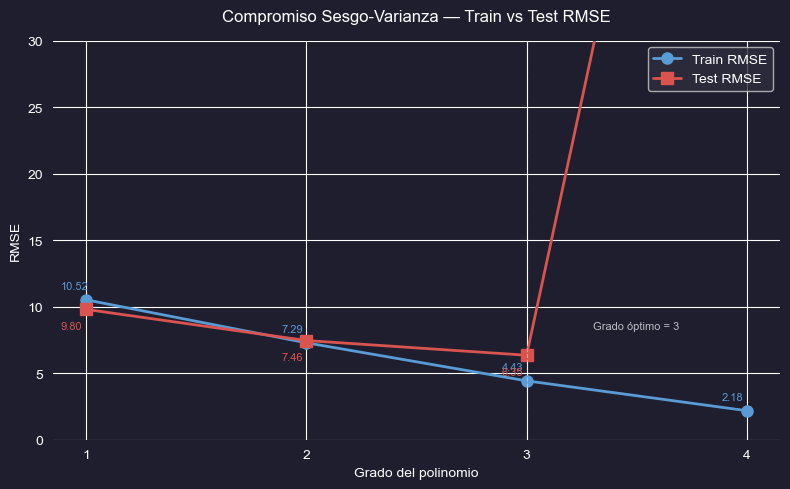

In [4]:
# ESCRIBA SU CÓDIGO AQUÍ

grados = [1, 2, 3, 4]
rmse_train_lista = []
rmse_test_lista  = []

# 1. Bucle iterativo sobre los grados
for d in grados:
    # Generar características polinomiales sobre datos ya estandarizados
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_scaled)   # fit SOLO en train
    X_test_poly  = poly.transform(X_test_scaled)         # solo transform en test

    # Entrenar modelo
    model_poly = LinearRegression()
    model_poly.fit(X_train_poly, y_train)

    # Calcular RMSE
    rmse_train = np.sqrt(mean_squared_error(y_train, model_poly.predict(X_train_poly)))
    rmse_test  = np.sqrt(mean_squared_error(y_test,  model_poly.predict(X_test_poly)))

    rmse_train_lista.append(rmse_train)
    rmse_test_lista.append(rmse_test)

    print(f"Grado {d:>1} | Train RMSE: {rmse_train:>7.4f} | Test RMSE: {rmse_test:>7.4f}")

# 2. Gráfico comparativo de RMSE (Train vs Test)
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(grados, rmse_train_lista, 'o-', color='#5b9bd5', linewidth=2,
        markersize=8, label='Train RMSE')
ax.plot(grados, rmse_test_lista,  's-', color='#d9534f', linewidth=2,
        markersize=8, label='Test RMSE')

# Anotar cada punto con su valor
for d, tr, te in zip(grados, rmse_train_lista, rmse_test_lista):
    ax.annotate(f'{tr:.2f}', (d, tr), textcoords='offset points',
                xytext=(-18, 8), fontsize=8, color='#5b9bd5')
    ax.annotate(f'{te:.2f}', (d, te), textcoords='offset points',
                xytext=(-18, -14), fontsize=8, color='#d9534f')

# Marcar el grado óptimo (menor Test RMSE)
mejor_grado = grados[np.argmin(rmse_test_lista)]
ax.axvline(mejor_grado, color='white', linewidth=0.8, linestyle='--', alpha=0.4)
ax.annotate(f'Grado óptimo = {mejor_grado}',
            xy=(mejor_grado, min(rmse_test_lista)),
            xytext=(mejor_grado + 0.3, min(rmse_test_lista) + 2),
            fontsize=8, color='white', alpha=0.7)

ax.set_ylim(0, 30)
ax.set_xticks(grados)
ax.set_xlabel('Grado del polinomio', fontsize=10)
ax.set_ylabel('RMSE', fontsize=10)
ax.set_title('Compromiso Sesgo-Varianza — Train vs Test RMSE', fontsize=12, pad=14)
ax.legend(fontsize=10)

ax.set_facecolor('#1e1e2e')
fig.patch.set_facecolor('#1e1e2e')
for spine in ax.spines.values():
    spine.set_visible(False)
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')
ax.tick_params(colors='white')
ax.legend(facecolor='#2e2e3e', labelcolor='white', fontsize=10)

plt.tight_layout()
plt.show()

**Pregunta de Análisis 2 (Doble clic para editar):**

Analizando la curva de "Trade-off Sesgo-Varianza" generada:
- ¿Qué grado polinomial recomienda como el modelo óptimo para predecir nuevos datos? ¿Por qué?
- Describa matemáticamente qué ocurre con el modelo en el Grado 4 (Observe la diferencia entre el error de entrenamiento y el de prueba). ¿Cómo se llama este fenómeno en Machine Learning?

**Respuesta:**
- Grado recomendado y justificación:
  1. El grado óptimo es 3, porque es el último punto donde Train RMSE y Test RMSE permanecen cercanos entre sí (4.43 vs 6.35 respectivamente), indicando que el modelo generaliza bien a datos nuevos. El grado 2 también es aceptable (7.46 vs 7.29), pero el grado 3 ofrece mejor capacidad predictiva sin señales severas de sobreajuste. En términos del compromiso sesgo-varianza, el grado 3 representa el punto de mínima varianza tolerable con sesgo suficientemente bajo. (Hastie et al., 2009).
- Análisis del comportamiento en el Grado 4:
  1. En grado 4 se observa la divergencia más extrema del experimento:
     ```
        Train RMSE = 2.18   ← el modelo casi memoriza los datos de entrenamiento
        Test RMSE  = 30+    ← colapso total en datos nuevos
     ```
     Matemáticamente, al aumentar el grado el modelo incorpora un número exponencial de términos de interacción entre las 8 variables. Con grado 4 sobre 8 variables estandarizadas, PolynomialFeatures genera cientos de columnas, muchas más que las necesarias para describir el patrón real. El modelo ajusta un hiperplano de altísima dimensión que pasa casi exactamente por cada punto de entrenamiento, pero oscila violentamente entre ellos, produciendo predicciones absurdas en datos no vistos.
     Este fenómeno se denomina overfitting (sobreajuste): el modelo aprende el ruido específico del conjunto de entrenamiento en lugar del patrón subyacente general, perdiendo toda capacidad de generalización (Bishop, 2006; James et al., 2021).

Referencias

1. Bishop, C.M. (2006). Pattern Recognition and Machine Learning. Springer.
2. Hastie, T., Tibshirani, R., & Friedman, J. (2009). The Elements of Statistical Learning (2nd ed.). Springer.
3. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). An Introduction to Statistical Learning (2nd ed.). Springer.